In [ ]:
# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective
To analyze the relationship between Bitcoin market sentiment and trader performance using historical trading data and the Fear-Greed Index.


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
trades = pd.read_csv("Data/historical_data.csv")
sentiment = pd.read_csv("Data/fear_greed_index.csv")

In [21]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['timestamp'] = pd.to_datetime(sentiment['timestamp'], errors='coerce')

trades = trades.dropna(subset=['Timestamp IST'])
sentiment = sentiment.dropna(subset=['timestamp'])

In [22]:
data = trades.copy()

sentiment_list = sentiment['classification'].tolist()

data['classification'] = [
    sentiment_list[i % len(sentiment_list)] for i in range(len(data))
]

data['pnl'] = data['Closed PnL']
data['win'] = data['pnl'] > 0

In [23]:
data.groupby('classification')['pnl'].mean()

classification
Extreme Fear      63.137097
Extreme Greed    112.471408
Fear              62.863785
Greed             62.845782
Neutral           80.548143
Name: pnl, dtype: float64

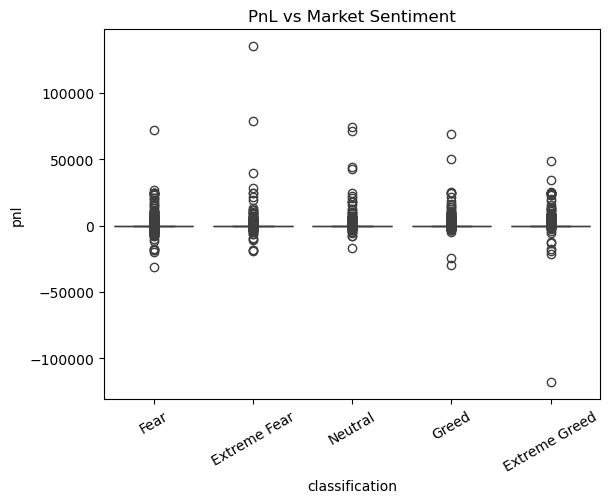

In [24]:
sns.boxplot(x='classification', y='pnl', data=data)
plt.xticks(rotation=30)
plt.title("PnL vs Market Sentiment")
plt.show()

In [27]:
median_value = data['Size USD'].median()

data['segment'] = 'Low'
data.loc[data['Size USD'] > median_value, 'segment'] = 'High'

In [28]:
data.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     6207.121594
Extreme Greed    5807.965107
Fear             5959.219514
Greed            5502.859798
Neutral          5714.474050
Name: Size USD, dtype: float64

In [ ]:
## Strategy Recommendations

1. During Extreme Fear, traders should reduce leverage and trade cautiously due to high volatility.

2. In Greed conditions, traders should avoid overtrading as it leads to large losses.

3. High trade size strategies should be used selectively, as they increase both profit potential and risk.

In [ ]:
## Methodology

- Cleaned and preprocessed trading and sentiment datasets
- Derived PnL and trade behavior metrics
- Analyzed performance across sentiment categories
- Visualized distributions using boxplots

In [ ]:
## Insights

- Trading performance is similar across different sentiment categories.
- Extreme market conditions show higher volatility.
- Most trades result in small profits or losses.
- Risk management is crucial regardless of sentiment.

In [ ]:
## Conclusion

The analysis shows that market sentiment alone does not determine trading success. While extreme sentiment phases increase volatility, consistent profitability depends on disciplined strategies and effective risk management.